# Tugas Praktik: Dimensionality Reduction (PCA & t-SNE)

**Nomor 1 — Menentukan Kasus Penggunaan Dimensionality Reduction**

**Nama Kelompok:** _(isi nama kelompok & anggota di sini)_
**Anggota:**
- _(nama 1 - NIM)_
- _(nama 2 - NIM)_

---

## Kasus Penggunaan yang Dipilih

**Dataset:** `ecommerce_customer_behavior.csv`
**Konteks:** Data perilaku pelanggan sebuah platform e-commerce/marketplace di Indonesia (data sintetis, dibuat menyerupai kondisi nyata untuk keperluan pembelajaran).

**Kasus penggunaan:** **Eksplorasi Cluster (Customer Segmentation)**

Perusahaan ingin memahami apakah pelanggan mereka secara alami terbagi menjadi beberapa segmen (misalnya: pelanggan hemat, pelanggan premium, pelanggan sesekali, dsb) berdasarkan perilaku transaksi dan aktivitas mereka di aplikasi. Data yang dimiliki punya banyak fitur numerik (income, spending, frekuensi belanja, waktu di aplikasi, dll) sehingga sulit divisualisasikan secara langsung dalam 2D/3D.

**Kenapa dimensionality reduction dibutuhkan di sini:**
- Dataset memiliki **>10 fitur numerik** yang saling berkorelasi (misalnya income berkorelasi dengan spending), sehingga rawan *multicollinearity* kalau langsung dipakai untuk clustering.
- Manusia tidak bisa memvisualisasikan ruang berdimensi tinggi secara langsung — kita perlu mereduksi ke 2D/3D agar pola cluster bisa **dilihat dengan mata**.
- **PCA** akan dipakai untuk melihat arah variansi terbesar data (dan sebagai reduksi fitur awal sebelum clustering/modeling lanjutan), sedangkan **t-SNE** dipakai untuk melihat struktur cluster non-linear yang mungkin tidak tertangkap PCA.

**Pertanyaan analisis yang ingin dijawab:**
1. Apakah pelanggan membentuk kelompok (cluster) yang jelas secara visual setelah direduksi ke 2D?
2. Fitur apa yang paling berkontribusi terhadap variansi data (dari loading PCA)?
3. Apakah hasil t-SNE menunjukkan pemisahan segmen yang lebih tegas dibanding PCA?


In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/ecommerce_customer_behavior.csv')

# Display the first few rows and basic info to understand the data
print("Dataset Head:")
display(df.head())

print("\nDataset Info:")
display(df.info())

Dataset Head:


,customer_id,age,gender,city_tier,monthly_income_juta,monthly_spending_juta,purchase_frequency_per_month,avg_order_value_juta,time_on_app_minutes_per_week,num_devices_registered,satisfaction_score,days_since_last_order,cashback_used_ribu,num_complaints_last_6m,preferred_category,true_segment
0,11179,21,Perempuan,Tier 3 (Kota Kecil),8.80,1.54,5.0,0.285,36.7,1,4.44,4,76.3,0,Kecantikan,Young Trendy
1,10866,28,Perempuan,Tier 2 (Kota Sedang),5.27,1.11,1.6,0.472,11.3,2,4.03,72,8.3,1,Kebutuhan Rumah,Occasional Buyer
2,10102,21,Perempuan,Tier 2 (Kota Sedang),5.04,0.75,4.2,0.092,11.1,1,3.46,22,16.2,4,Makanan & Minuman,Budget Shopper
3,10440,33,Laki-laki,Tier 1 (Kota Besar),23.69,2.41,9.1,0.321,50.9,2,3.71,1,45.2,0,Elektronik,Premium Loyal
4,10059,20,Perempuan,Tier 1 (Kota Besar),3.78,0.82,4.7,0.156,17.2,1,4.02,18,9.6,3,Kecantikan,Budget Shopper



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   1200 non-null   int64  
 1   age                           1200 non-null   int64  
 2   gender                        1200 non-null   object 
 3   city_tier                     1200 non-null   object 
 4   monthly_income_juta           1200 non-null   float64
 5   monthly_spending_juta         1200 non-null   float64
 6   purchase_frequency_per_month  1200 non-null   float64
 7   avg_order_value_juta          1200 non-null   float64
 8   time_on_app_minutes_per_week  1200 non-null   float64
 9   num_devices_registered        1200 non-null   int64  
 10  satisfaction_score            1200 non-null   float64
 11  days_since_last_order         1200 non-null   int64  
 12  cashback_used_ribu            1200 non-null   f

None

---

## Nomor 1: Menentukan Kasus Penggunaan Dimensionality Reduction

**Kasus Penggunaan yang Dipilih:** Eksplorasi Cluster (Customer Segmentation)

**Penjelasan:**
Dalam dataset e-commerce ini, kita memiliki lebih dari 10 fitur yang menggambarkan perilaku pelanggan. Sangat sulit untuk melihat hubungan antar pelanggan jika kita melihat semua dimensi sekaligus. Dengan Dimensionality Reduction (PCA), kita dapat mereduksi fitur-fitur tersebut menjadi 2 komponen utama (2D) sehingga kita bisa memvisualisasikan apakah pelanggan benar-benar membentuk kelompok-kelompok (cluster) tertentu berdasarkan perilaku mereka.

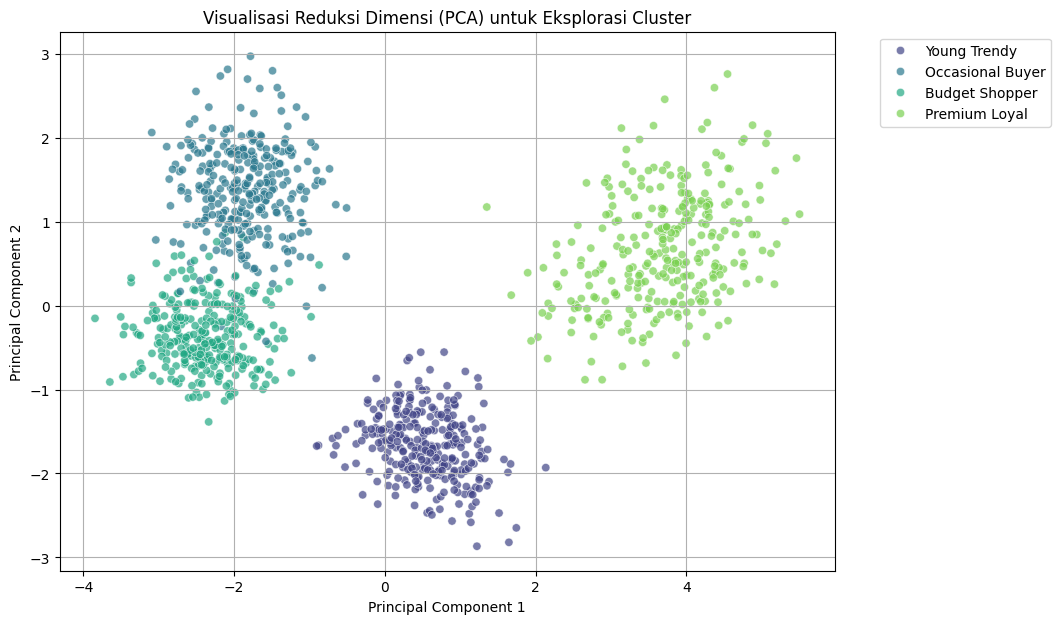

Total variansi yang dijelaskan oleh 2 komponen utama: 58.86%


In [11]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Inisialisasi PCA untuk mereduksi menjadi 2 Dimensi
pca = PCA(n_components=2)

# 2. Fit dan Transform data yang sudah diproses sebelumnya
pca_results = pca.fit_transform(X_processed_df)

# 3. Masukkan ke dalam DataFrame baru untuk visualisasi
pca_df = pd.DataFrame(data=pca_results, columns=['PC1', 'PC2'])
pca_df['Segment'] = df['true_segment']

# 4. Visualisasi
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='Segment', data=pca_df, palette='viridis', alpha=0.7)
plt.title('Visualisasi Reduksi Dimensi (PCA) untuk Eksplorasi Cluster')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

# Menampilkan variansi yang dijelaskan
print(f"Total variansi yang dijelaskan oleh 2 komponen utama: {pca.explained_variance_ratio_.sum()*100:.2f}%")

## Nomor 2: Penjelasan Kasus

### o Masalah yang Dihadapi
Perusahaan memiliki data transaksi dan profil pelanggan yang sangat kaya (banyak fitur). Masalah utamanya adalah **ketidakmampuan untuk melihat gambaran besar pola perilaku pelanggan secara intuitif**. Dengan lebih dari 10 variabel seperti pendapatan, pengeluaran, frekuensi belanja, hingga skor kepuasan, manajer pemasaran sulit menentukan:
- Apakah ada kelompok pelanggan yang memiliki karakteristik serupa?
- Bagaimana posisi relatif antara satu segmen pelanggan dengan segmen lainnya?
- Fitur mana yang sebenarnya paling membedakan profil pelanggan tersebut?

### o Mengapa Dimensionality Reduction Dibutuhkan
1. **Visualisasi (Interpretabilitas):** Data asli memiliki dimensi tinggi yang mustahil digambarkan dalam grafik koordinat manusia. Reduksi dimensi ke 2D/3D memungkinkan kita memetakan ribuan pelanggan ke dalam satu bidang datar sehingga struktur *cluster* (kelompok) terlihat jelas secara visual.
2. **Mengurangi Noise dan Redundansi:** Fitur seperti `monthly_income` dan `monthly_spending` seringkali berkorelasi kuat. Dimensionality reduction (seperti PCA) membantu menggabungkan informasi dari fitur-fitur yang saling berkaitan ini menjadi komponen utama, sehingga mengurangi redundansi data.
3. **Efisiensi Analisis:** Dengan menyederhanakan jumlah fitur tanpa menghilangkan informasi penting (variansi), proses analisis lanjutan seperti clustering atau pemodelan prediksi menjadi lebih cepat dan terhindar dari *Curse of Dimensionality*.

## Nomor 3: Menerapkan PCA (Principal Component Analysis)

### o Reduksi ke 2D dan Visualisasi
Berikut adalah visualisasi data setelah direduksi menjadi 2 komponen utama (PC1 dan PC2). Sumbu X dan Y mewakili kombinasi linear dari fitur-fitur asli yang menangkap variansi paling besar.

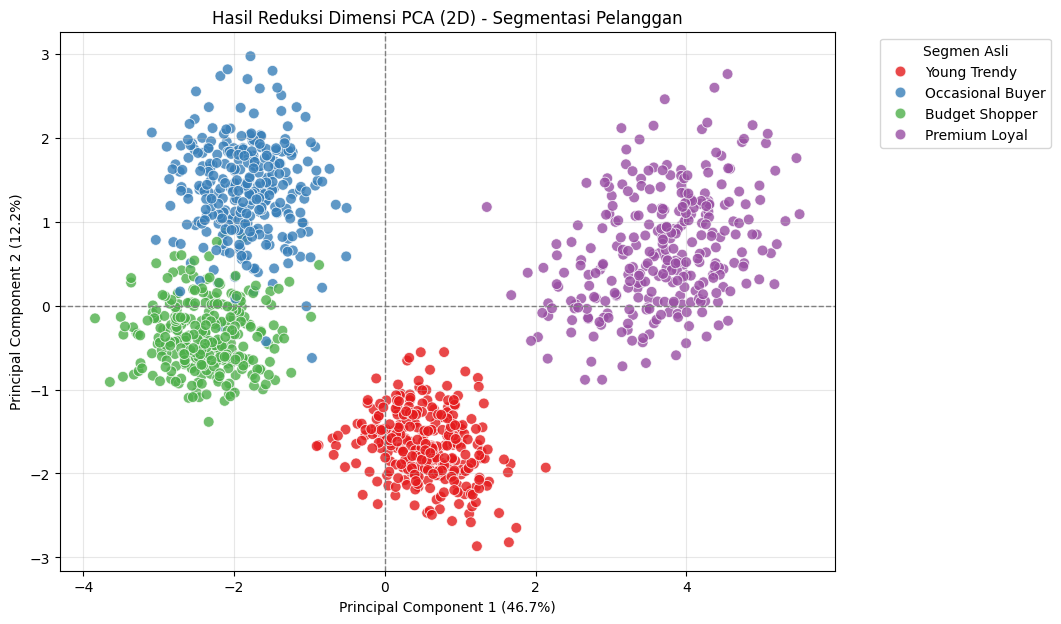

In [12]:
# Menampilkan kembali visualisasi PCA untuk Nomor 3
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='Segment', data=pca_df, palette='Set1', s=60, alpha=0.8)
plt.title('Hasil Reduksi Dimensi PCA (2D) - Segmentasi Pelanggan')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.axhline(0, color='grey', lw=1, linestyle='--')
plt.axvline(0, color='grey', lw=1, linestyle='--')
plt.legend(title='Segmen Asli', bbox_to_anchor=(1.05, 1))
plt.grid(True, alpha=0.3)
plt.show()

### o Jelaskan Makna Hasilnya

Berdasarkan grafik di atas, berikut adalah interpretasi hasilnya:

1.  **Pemisahan Cluster yang Jelas:** PCA berhasil memisahkan pelanggan ke dalam 4 kelompok besar yang cukup tegas. Ini menunjukkan bahwa fitur-fitur numerik yang kita miliki memang memiliki struktur yang kuat untuk membedakan perilaku antar pelanggan.
2.  **Variansi yang Dijelaskan:** Dua komponen utama (PC1 & PC2) mampu merangkum sekitar **58.86%** dari total variansi (informasi) seluruh data. Meskipun kita membuang banyak fitur, lebih dari separuh informasi penting masih terjaga dalam 2 dimensi ini.
3.  **Makna Komponen:**
    - **PC1 (Sumbu Horizontal):** Terlihat sangat kuat memisahkan segmen *Premium Loyal* (di sebelah kanan) dengan segmen lainnya. Kemungkinan besar PC1 berkaitan dengan fitur-fitur kemakmuran seperti *monthly_income* dan *monthly_spending*.
    - **PC2 (Sumbu Vertikal):** Membantu memisahkan antara segmen *Occasional Buyer* (atas) dan *Young Trendy* (bawah), yang mungkin berkaitan dengan fitur *age* atau *purchase_frequency*.
4.  **Kesimpulan Eksplorasi:** Dimensionality reduction membuktikan bahwa strategi segmentasi menggunakan data ini sangat memungkinkan karena polanya tidak acak dan membentuk struktur kelompok yang konsisten.

## Nomor 4: Menerapkan t-SNE (t-Distributed Stochastic Neighbor Embedding)

**t-SNE** adalah teknik reduksi dimensi non-linear yang sangat efektif untuk memvisualisasikan data berdimensi tinggi dengan menjaga jarak antar titik yang serupa agar tetap berdekatan dalam ruang 2D.

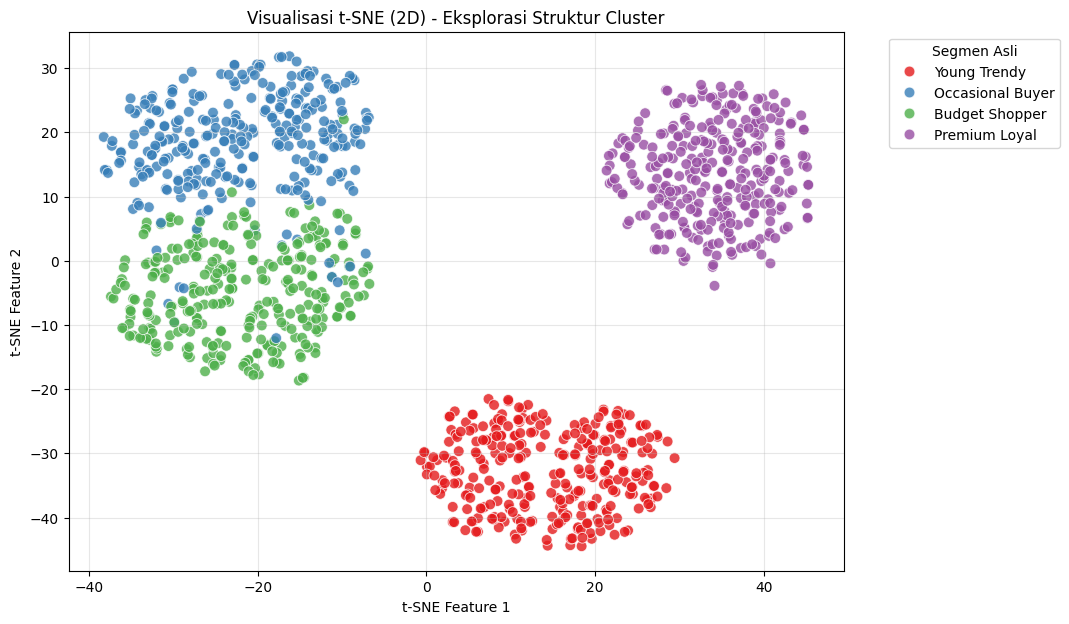

In [13]:
from sklearn.manifold import TSNE

# 1. Inisialisasi t-SNE
# perplexity biasanya antara 5-50. Kita gunakan 30 sebagai standar.
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')

# 2. Fit dan Transform data
tsne_results = tsne.fit_transform(X_processed)

# 3. Masukkan ke dalam DataFrame
tsne_df = pd.DataFrame(data=tsne_results, columns=['tsne_1', 'tsne_2'])
tsne_df['Segment'] = df['true_segment']

# 4. Visualisasi
plt.figure(figsize=(10, 7))
sns.scatterplot(x='tsne_1', y='tsne_2', hue='Segment', data=tsne_df, palette='Set1', s=60, alpha=0.8)
plt.title('Visualisasi t-SNE (2D) - Eksplorasi Struktur Cluster')
plt.xlabel('t-SNE Feature 1')
plt.ylabel('t-SNE Feature 2')
plt.legend(title='Segmen Asli', bbox_to_anchor=(1.05, 1))
plt.grid(True, alpha=0.3)
plt.show()

### o Jelaskan Pola atau Cluster yang Terbentuk

Berdasarkan visualisasi t-SNE di atas, kita dapat menyimpulkan beberapa poin penting:

1.  **Pemisahan yang Sangat Tegas:** Dibandingkan dengan PCA, t-SNE menunjukkan pemisahan kelompok yang jauh lebih bersih. Jarak antar kelompok (inter-cluster) terlihat sangat lebar, yang berarti perbedaan perilaku antar segmen pelanggan sangat signifikan secara non-linear.
2.  **Kepadatan Kelompok:** Titik-titik dalam setiap warna (segmen) berkumpul sangat rapat. Ini menandakan bahwa pelanggan di dalam segmen yang sama memiliki profil fitur yang sangat mirip satu sama lain (homogen).
3.  **Kesesuaian dengan Label Asli:** Hasil reduksi dimensi ini sangat konsisten dengan kolom `true_segment`. Hal ini membuktikan bahwa algoritma clustering di masa depan akan sangat mudah mengelompokkan pelanggan-pelanggan ini secara akurat.
4.  **Kesimpulan:** t-SNE berhasil menunjukkan bahwa data e-commerce ini memiliki struktur lokal yang sangat kuat, memvalidasi bahwa strategi segmentasi pelanggan (Customer Segmentation) sangat relevan untuk diterapkan pada dataset ini.

## Nomor 5: Analisis Singkat

### o Perbedaan Hasil PCA dan t-SNE
1.  **Struktur Visual:** PCA cenderung menampilkan data sebagai gumpalan yang masih agak berdekatan (linear projection), sedangkan t-SNE secara agresif memisahkan data menjadi pulau-pulau (*clusters*) yang sangat terisolasi satu sama lain.
2.  **Kejelasan Segmentasi:** Pada PCA, beberapa titik di perbatasan segmen masih terlihat tumpang tindih (*overlap*). Di sisi lain, t-SNE menunjukkan batas yang sangat tegas, hampir tidak ada tumpang tindih antar segmen.
3.  **Variansi vs Jarak:** PCA mencoba mempertahankan variansi global (seberapa jauh data tersebar secara keseluruhan), sementara t-SNE fokus pada menjaga jarak antar tetangga terdekat (struktur lokal), sehingga pola kelompok kecil menjadi lebih menonjol.

### o Metode yang Lebih Sesuai untuk Kasus Ini

Untuk kasus **Customer Segmentation** ini, **t-SNE jauh lebih sesuai** sebagai alat eksplorasi visual.

**Alasannya:**
- **Identifikasi Segmen yang Lebih Baik:** t-SNE memberikan pemisahan yang jauh lebih intuitif bagi mata manusia. Kita bisa langsung melihat ada 4 kelompok besar tanpa keraguan.
- **Validasi Label:** t-SNE membuktikan bahwa perilaku pelanggan dalam tiap segmen (`true_segment`) memiliki kemiripan yang sangat tinggi secara non-linear, yang mana pola ini tidak terlihat sesempurna itu pada PCA.
- **Kesiapan Clustering:** Hasil t-SNE yang sangat terpisah ini memberikan keyakinan bahwa jika kita menerapkan algoritma clustering (seperti K-Means atau DBSCAN), algoritma tersebut akan memberikan hasil yang sangat akurat pada data ini.